Carregar dados

In [1]:
import pandas as pd

# carregar dados
df = pd.read_csv("../data/processed/LigaPortugal17-26.csv")

# ordenar por data, mais antigo primeiro
df = df.sort_values(by=['Date', 'Time', 'HomeTeam'], ascending=[True, True, True]).reset_index(drop=True)
#df = df.iloc[::-1].reset_index(drop=True)

Features e Target

In [2]:
from sklearn.preprocessing import LabelEncoder
# colunas para teste treino
features = [
    'HomeRank', 'AwayRank', 'HomePoints', 'AwayPoints',
    'HomeW', 'AwayW', 'HomeGD', 'AwayGD', 'HomeGP', 'AwayGP',
    'Sum_HomeY', 'Sum_AwayY', 'Sum_HomeR', 'Sum_AwayR',
    'Stadium', 'Home_L5_GS', 'Home_L5_GC', 'Home_L5_Form_Pts',
    'Away_L5_GS', 'Away_L5_GC', 'Away_L5_Form_Pts',
    'Rank_Diff', 'Form_Diff', 'GD_Diff', 'HomePPG', 'AwayPPG',
    'PPG_Diff', 'HomeGDpg', 'AwayGDpg', 'GDpg_Diff', 'WeatherSeason'
]

X = df[features]
y = df['FTR']

# transformar FTR em numerico
le = LabelEncoder()
y_numeric = le.fit_transform(y)

# dizer quais sao as classes A => 0, D => 1, H =>2
print("Classes e números correspondentes:",dict(zip(le.classes_, map(int, le.transform(le.classes_)))))

Classes e números correspondentes: {'A': 0, 'D': 1, 'H': 2}


Split temporal de Treino e Teste

In [3]:
# treino epocas 17-18 a 23-24
season_train = ['17-18', '18-19', '19-20', '20-21', '21-22', '22-23', '23-24']
season_test = ['24-25', '25-26']

# criar boolean masks
mask_train = df['Season'].isin(season_train)
mask_test = df['Season'].isin(season_test)

X_train, X_test = X[mask_train], X[mask_test]
y_train, y_test = y_numeric[mask_train], y_numeric[mask_test]

print(f'Nº jogos de treino (17-18 a 23-24): {len(X_train)}')
print(f'Nº jogos de teste (24-25 a 25-26): {len(X_test)}')

Nº jogos de treino (17-18 a 23-24): 2142
Nº jogos de teste (24-25 a 25-26): 612


Modelo XGBoost base (sem parametros definidos)

In [4]:
import xgboost as xgb

model_xgb = xgb.XGBClassifier(random_state=42, objective="multisoftprob", num_class=3, eval_metric="mlogloss")
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

Avaliação do modelo base

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef, precision_recall_curve, log_loss

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'MCC: {matthews_corrcoef(y_test, y_pred):.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_)) # ja inclui f1 scores
print(f"Log loss: {log_loss(y_test, model_xgb.predict_proba(X_test))}")

Accuracy: 0.4951
MCC: 0.2148
Classification Report:
              precision    recall  f1-score   support

           A       0.50      0.53      0.51       192
           D       0.34      0.22      0.27       162
           H       0.54      0.64      0.59       258

    accuracy                           0.50       612
   macro avg       0.46      0.46      0.46       612
weighted avg       0.48      0.50      0.48       612

Log loss: 1.267576001545027


Matriz Confusão

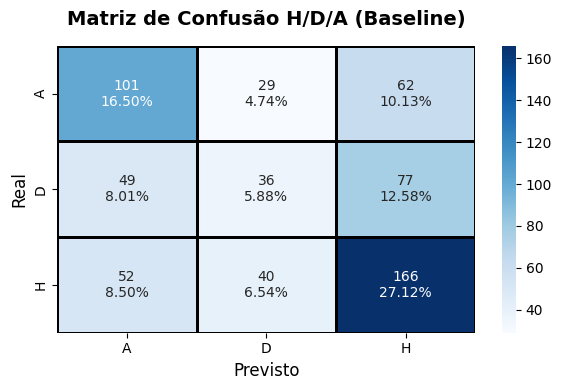

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# matriz de confusao
cm = confusion_matrix(y_test, y_pred)

# obter contagens e formatar
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]

# obter percentagens relativas ao total e formatar
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts,group_percentages)]

labels = np.asarray(labels).reshape(3,3)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, linewidths=1, linecolor='black')

plt.title('Matriz de Confusão H/D/A (Baseline)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Precision-Recall Curve

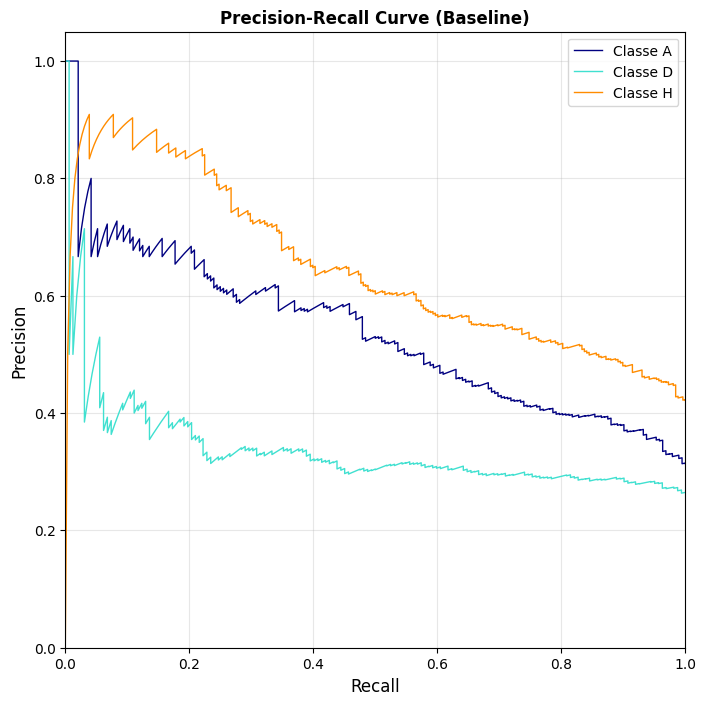

In [25]:
from sklearn.preprocessing import label_binarize

Y = label_binarize(y_test, classes=[0, 1, 2])
n_classes = Y.shape[1]

# obter probabilidades do modelo
y_prob = model_xgb.predict_proba(X_test)

from itertools import cycle

colors = cycle(['navy', 'turquoise', 'darkorange'])

plt.figure(figsize=(8,8))

# criar a curva para cada classe
for i, color, class_label in zip(range(n_classes), colors, le.classes_):
    precision, recall, _ = precision_recall_curve(Y[:,i], y_prob[:,i])
    
    plt.plot(recall, precision, color=color, lw=1, label=f"Classe {class_label}")

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve (Baseline)', fontweight='bold')
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

Feature Importance

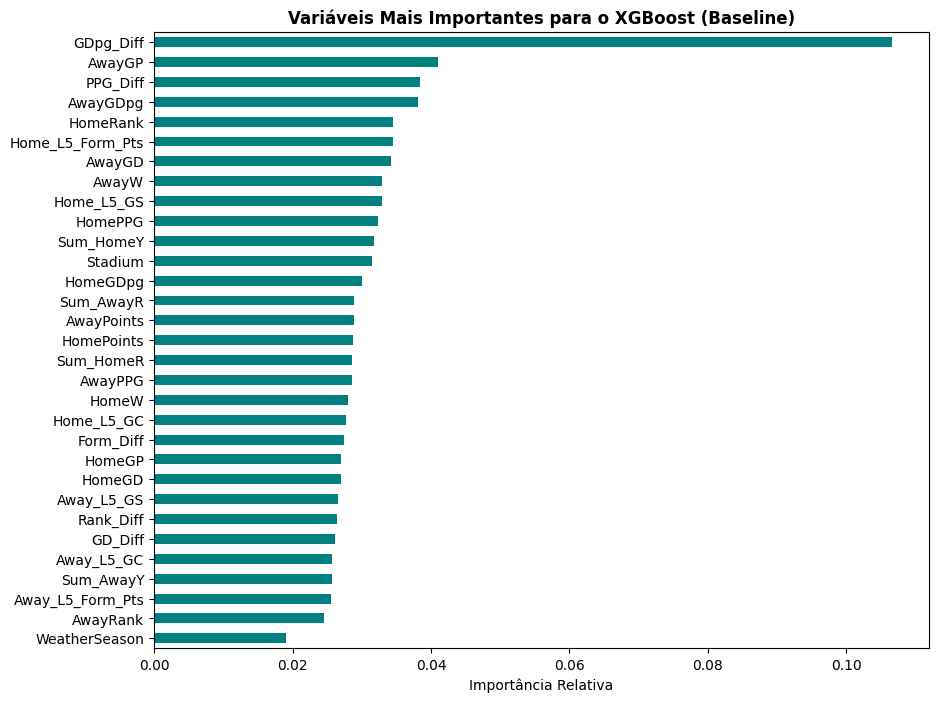

In [24]:
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(model_xgb.feature_importances_, index=X.columns)
feat_importances.nlargest(31).sort_values().plot(kind='barh', color='teal')
plt.title("Variáveis Mais Importantes para o XGBoost (Baseline)", fontweight='bold')
plt.xlabel("Importância Relativa")
plt.show()

Optuna

In [9]:
from sklearn.metrics import f1_score, log_loss
import optuna

season_train = ['17-18', '18-19', '19-20', '20-21', '21-22']
season_val = ['22-23', '23-24']

mask_train = df['Season'].isin(season_train)
mask_val = df['Season'].isin(season_val)

X_tr, X_val = X[mask_train], X[mask_val]
y_tr, y_val = y_numeric[mask_train], y_numeric[mask_val]

print(f'Nº jogos de treino (17-18 a 21-22): {len(X_tr)}')
print(f'Nº jogos de teste (22-23 a 23-24): {len(X_val)}')

def objective(trial):
    params ={
        "objective" : "multi:softprob",
        "num_class" : 3,
        "eval_metric" : "mlogloss",
        
        "learning_rate" : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth" : trial.suggest_int("max_depth", 4, 7),
        "n_estimators" : trial.suggest_int("n_estimators", 400, 1000),
        
        "subsample" : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        
        "min_child_weight" : trial.suggest_int("min_child_weight", 2, 10),
        "gamma" : trial.suggest_float("gamma", 0.1, 5.0, log=True),
        "reg_lambda" : trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "reg_alpha" : trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True)
        }
        
    model_xgb = xgb.XGBClassifier(**params)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    #y_pred_val = model_xgb.predict(X_val)
    y_pred_val_proba = model_xgb.predict_proba(X_val)
    # mcc = matthews_corrcoef(y_val, y_pred_val)
    #f1 = f1_score(y_val, y_pred_val, average="macro")
    loss = log_loss(y_val, y_pred_val_proba)
    
    return loss

Nº jogos de treino (17-18 a 21-22): 1530
Nº jogos de teste (22-23 a 23-24): 612


c:\Users\andre\Documents\PEC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
best_params = study.best_params
print(f"Melhores hiperparametros: {best_params}")

best_score = study.best_value
print(f"Melhor Loss: {best_score:.3f}")

[I 2026-04-14 14:47:31,635] A new study created in memory with name: no-name-b2ee76ca-20b0-43d3-a18c-41ce9b10fa5f
[I 2026-04-14 14:47:33,393] Trial 0 finished with value: 0.9933686278232436 and parameters: {'learning_rate': 0.024316396872954553, 'max_depth': 4, 'n_estimators': 794, 'subsample': 0.8636674226216682, 'colsample_bytree': 0.5072289741260527, 'min_child_weight': 8, 'gamma': 0.7078950947686569, 'reg_lambda': 0.019652513283180635, 'reg_alpha': 0.0011181314352503471}. Best is trial 0 with value: 0.9933686278232436.
[I 2026-04-14 14:47:34,681] Trial 1 finished with value: 0.9536891919741197 and parameters: {'learning_rate': 0.030270295469180763, 'max_depth': 4, 'n_estimators': 852, 'subsample': 0.8395985440447482, 'colsample_bytree': 0.9847400790407994, 'min_child_weight': 9, 'gamma': 2.0051317999575295, 'reg_lambda': 0.013638013042192016, 'reg_alpha': 0.0024717238149202974}. Best is trial 1 with value: 0.9536891919741197.
[I 2026-04-14 14:47:35,763] Trial 2 finished with value:

Melhores hiperparametros: {'learning_rate': 0.15126766673915848, 'max_depth': 6, 'n_estimators': 422, 'subsample': 0.9371543391575077, 'colsample_bytree': 0.9206831318413401, 'min_child_weight': 6, 'gamma': 3.3894775369915258, 'reg_lambda': 0.01156311748437383, 'reg_alpha': 0.2752277707681487}
Melhor Loss: 0.927


In [11]:
optuna.visualization.plot_optimization_history(study)

In [12]:
optuna.visualization.plot_slice(study)

In [13]:
optuna.visualization.plot_param_importances(study)

In [10]:
final_model = xgb.XGBClassifier(objective="multi:softprob",
        num_class=3, random_state=42,learning_rate=0.15126766673915848, max_depth=6, n_estimators=422, subsample=0.9371543391575077, colsample_bytree=0.9206831318413401, min_child_weight=6, gamma=3.3894775369915258, reg_lambda=0.01156311748437383, reg_alpha=0.2752277707681487)

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred_final):.4f}')
print(f'MCC: {matthews_corrcoef(y_test, y_pred_final):.4f}')
print(f1_score(y_test, y_pred_final, average="macro"))
print('Classification Report:')
print(classification_report(y_test, y_pred_final, target_names=le.classes_))
print(f"Log loss: {log_loss(y_test, final_model.predict_proba(X_test))}")

Accuracy: 0.5278
MCC: 0.2620
0.41478106529087727
Classification Report:
              precision    recall  f1-score   support

           A       0.54      0.52      0.53       192
           D       0.50      0.04      0.07       162
           H       0.52      0.84      0.64       258

    accuracy                           0.53       612
   macro avg       0.52      0.47      0.41       612
weighted avg       0.52      0.53      0.46       612

Log loss: 0.9608945631548961


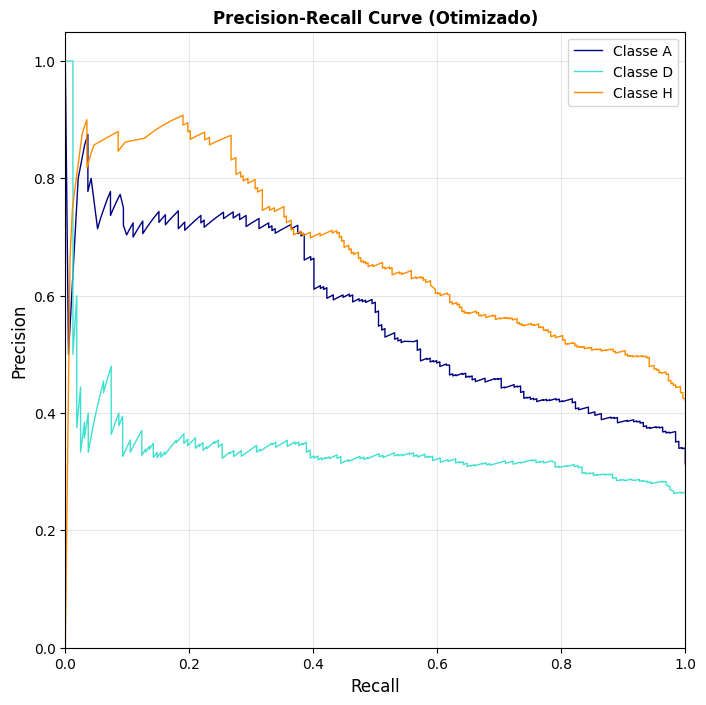

In [23]:
# obter probabilidades do modelo
y_prob_final = final_model.predict_proba(X_test)

colors = cycle(['navy', 'turquoise', 'darkorange'])

plt.figure(figsize=(8,8))

# criar a curva para cada classe
for i, color, class_label in zip(range(n_classes), colors, le.classes_):
    precision, recall, _ = precision_recall_curve(Y[:,i], y_prob_final[:,i])
    
    plt.plot(recall, precision, color=color, lw=1, label=f"Classe {class_label}")

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve (Otimizado)', fontweight='bold')
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

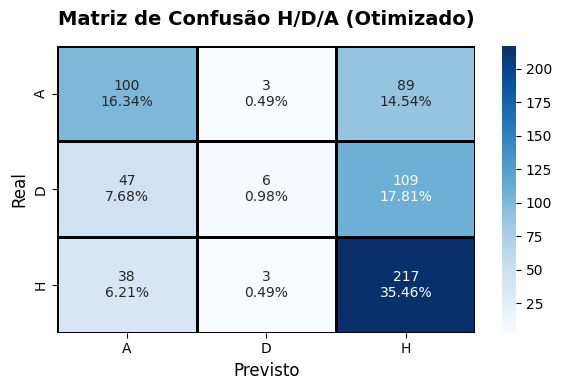

In [22]:
# matriz de confusao
cm_final = confusion_matrix(y_test, y_pred_final)

# obter contagens e formatar
group_counts = ["{0:0.0f}".format(value) for value in cm_final.flatten()]

# obter percentagens relativas ao total e formatar
group_percentages = ["{0:.2%}".format(value) for value in cm_final.flatten()/np.sum(cm_final)]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts,group_percentages)]

labels = np.asarray(labels).reshape(3,3)

plt.figure(figsize=(6,4))
sns.heatmap(cm_final, annot=labels, fmt='', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, linewidths=1, linecolor='black')

plt.title('Matriz de Confusão H/D/A (Otimizado)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

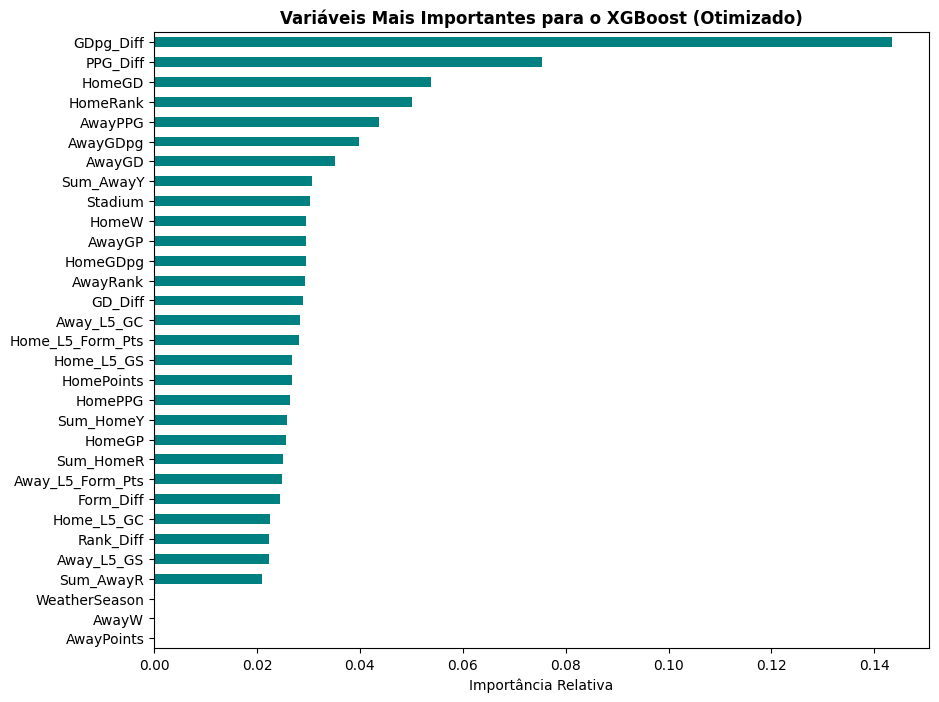

In [27]:
plt.figure(figsize=(10, 8))
final_feat_importances = pd.Series(final_model.feature_importances_, index=X.columns)
final_feat_importances.nlargest(31).sort_values().plot(kind='barh', color='teal')
plt.title("Variáveis Mais Importantes para o XGBoost (Otimizado)", fontweight='bold')
plt.xlabel("Importância Relativa")
plt.show()

Ablation Study

In [14]:
# definir as features a remover, normalmente o que esta no fim do importance feature grafico
features_to_remove = [
    'WeatherSeason',
    'Sum_AwayR', 'Sum_HomeR',# 'Sum_AwayY', 'Sum_HomeY',
    'AwayPoints', 'HomePoints',
    'AwayW', 'HomeW'
    #'AwayGP', 'HomeGP',
    #'Form_Diff', 'Away_L5_GS', 'Away_L5_GC', 'Home_L5,GS', 'Home_L5_GC'
]

# criar a nova lista de features reduzidas
features_reduced = [f for f in features if f not in features_to_remove]

print(f"Número de features originais: {len(features)}")
print(f"Número de features após redução: {len(features_reduced)}")

X_train_reduced = X_train[features_reduced]
X_test_reduced = X_test[features_reduced]

# treinar um novo modelo com os exatos mesmos hiperparâmetros
modelo_reduced = xgb.XGBClassifier(learning_rate=0.15126766673915848, max_depth=6, n_estimators=422, subsample=0.9371543391575077, colsample_bytree=0.9206831318413401, min_child_weight=6, gamma=3.3894775369915258, reg_lambda=0.01156311748437383, reg_alpha=0.2752277707681487,objective="multi:softprob",
        num_class=3,
        random_state=42)
modelo_reduced.fit(X_train_reduced, y_train)

# calcular e comparar os Log Loss
ll_original = log_loss(y_test, final_model.predict_proba(X_test))
ll_reduced = log_loss(y_test, modelo_reduced.predict_proba(X_test_reduced))

print("-" * 50)
print(f'MCC: {matthews_corrcoef(y_test, modelo_reduced.predict(X_test_reduced)):.4f}')
print(f1_score(y_test, modelo_reduced.predict(X_test_reduced), average="macro"))
print('Classification Report:')
print(classification_report(y_test, modelo_reduced.predict(X_test_reduced), target_names=le.classes_))
print("-" * 50)
print(f"Log Loss (Todas as Features): {ll_original:.5f}")
print(f'Accuracy (Todas as Features): {accuracy_score(y_test, final_model.predict(X_test)):.4f}')
print(f"Log Loss (Features Reduzidas): {ll_reduced:.5f}")
print(f'Accuracy (Features Reduzidas): {accuracy_score(y_test, modelo_reduced.predict(X_test_reduced)):.4f}')

Número de features originais: 31
Número de features após redução: 24
--------------------------------------------------
MCC: 0.2593
0.4070259726612644
Classification Report:
              precision    recall  f1-score   support

           A       0.56      0.53      0.54       192
           D       0.25      0.02      0.03       162
           H       0.52      0.84      0.64       258

    accuracy                           0.53       612
   macro avg       0.44      0.46      0.41       612
weighted avg       0.46      0.53      0.45       612

--------------------------------------------------
Log Loss (Todas as Features): 0.96089
Accuracy (Todas as Features): 0.5278
Log Loss (Features Reduzidas): 0.95450
Accuracy (Features Reduzidas): 0.5261


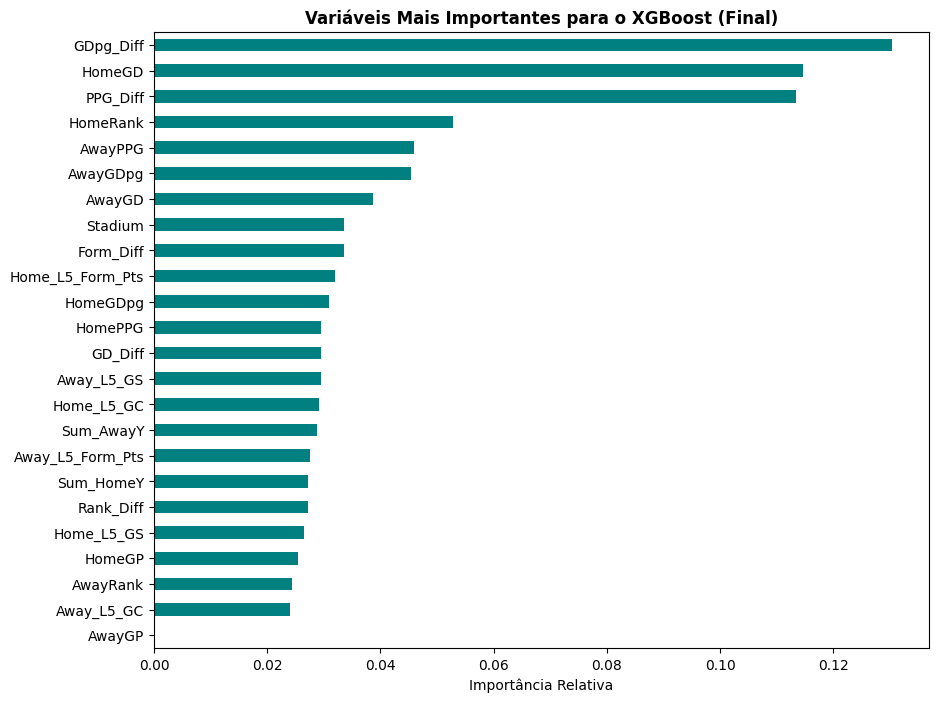

In [50]:
plt.figure(figsize=(10, 8))
X_reduced = df[features_reduced]
final_feat_importances = pd.Series(modelo_reduced.feature_importances_, index=X_reduced.columns)
final_feat_importances.nlargest(24).sort_values().plot(kind='barh', color='teal')
plt.title("Variáveis Mais Importantes para o XGBoost (Final)", fontweight='bold')
plt.xlabel("Importância Relativa")
plt.show()

Matriz de Confusao modelo reduzido

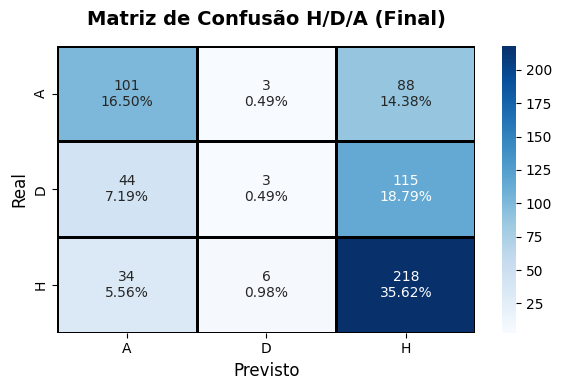

In [21]:
# matriz de confusao
y_pred_final_reduced = modelo_reduced.predict(X_test_reduced)
cm_final_reduced = confusion_matrix(y_test, y_pred_final_reduced)

# obter contagens e formatar
group_counts = ["{0:0.0f}".format(value) for value in cm_final_reduced.flatten()]

# obter percentagens relativas ao total e formatar
group_percentages = ["{0:.2%}".format(value) for value in cm_final_reduced.flatten()/np.sum(cm_final_reduced)]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts,group_percentages)]

labels = np.asarray(labels).reshape(3,3)

plt.figure(figsize=(6,4))
sns.heatmap(cm_final_reduced, annot=labels, fmt='', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, linewidths=1, linecolor='black')

plt.title('Matriz de Confusão H/D/A (Final)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Precision Recall reduzido

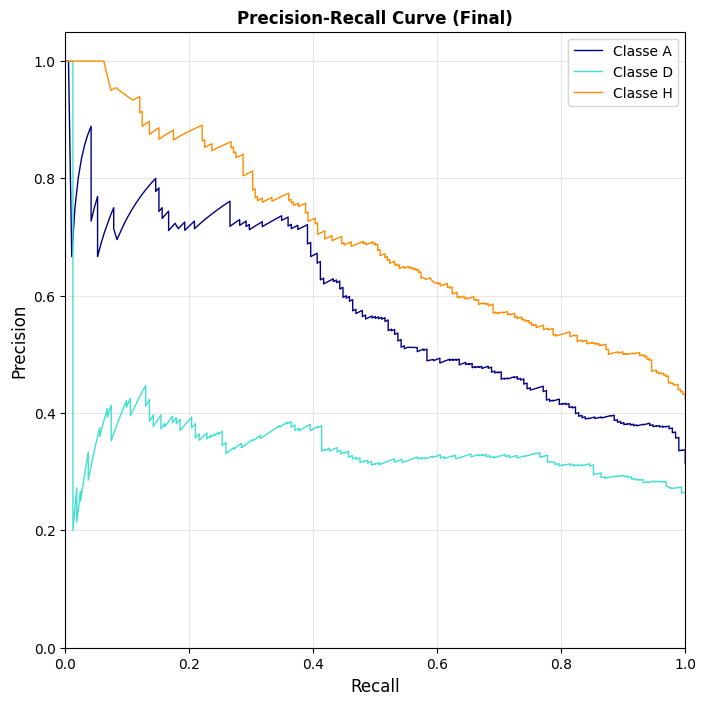

In [28]:
# obter probabilidades do modelo
y_prob_final_reduced = modelo_reduced.predict_proba(X_test_reduced)

colors = cycle(['navy', 'turquoise', 'darkorange'])

plt.figure(figsize=(8,8))

# criar a curva para cada classe
for i, color, class_label in zip(range(n_classes), colors, le.classes_):
    precision, recall, _ = precision_recall_curve(Y[:,i], y_prob_final_reduced[:,i])
    
    plt.plot(recall, precision, color=color, lw=1, label=f"Classe {class_label}")


plt.xlabel('Recall', fontsize=12,)
plt.ylabel('Precision', fontsize=12,)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve (Final)', fontweight='bold')
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

Brier Score e Curva de calibração

In [29]:
from sklearn.metrics import brier_score_loss
# calcular brier score global
y_prob_final_reduced = modelo_reduced.predict_proba(X_test_reduced)
brier_global = np.mean(np.sum((y_prob - Y)**2, axis=1))
final_brier_global = np.mean(np.sum((y_prob_final - Y)**2, axis=1))
final_reduced_brier_global = np.mean(np.sum((y_prob_final_reduced - Y)**2, axis=1))
print(f"Brier Score Global (Baseline): {brier_global:.4f}")
print(f"Brier Score Global (Otimizado): {final_brier_global:.4f}")
print(f"Brier Score Global (Reduzido): {final_reduced_brier_global:.4f}")

# calcular brier score por classe
for i, class_label in enumerate(le.classes_):
    bs_base = brier_score_loss(Y[:,i], y_prob[:,i])
    bs_final = brier_score_loss(Y[:,i], y_prob_final[:,i])
    bs_reduced = brier_score_loss(Y[:,i], y_prob_final_reduced[:,i])
    
    print("-" * 50)
    print(f"Brier Score Classe {class_label} (Baseline): {bs_base:.4f}")
    print(f"Brier Score Classe {class_label} (Otimizado): {bs_final:.4f}")
    print(f"Brier Score Classe {class_label} (Reduzido): {bs_reduced:.4f}")

Brier Score Global (Baseline): 0.6798
Brier Score Global (Otimizado): 0.5707
Brier Score Global (Reduzido): 0.5660
--------------------------------------------------
Brier Score Classe A (Baseline): 0.2140
Brier Score Classe A (Otimizado): 0.1782
Brier Score Classe A (Reduzido): 0.1766
--------------------------------------------------
Brier Score Classe D (Baseline): 0.2225
Brier Score Classe D (Otimizado): 0.1907
Brier Score Classe D (Reduzido): 0.1898
--------------------------------------------------
Brier Score Classe H (Baseline): 0.2434
Brier Score Classe H (Otimizado): 0.2019
Brier Score Classe H (Reduzido): 0.1996


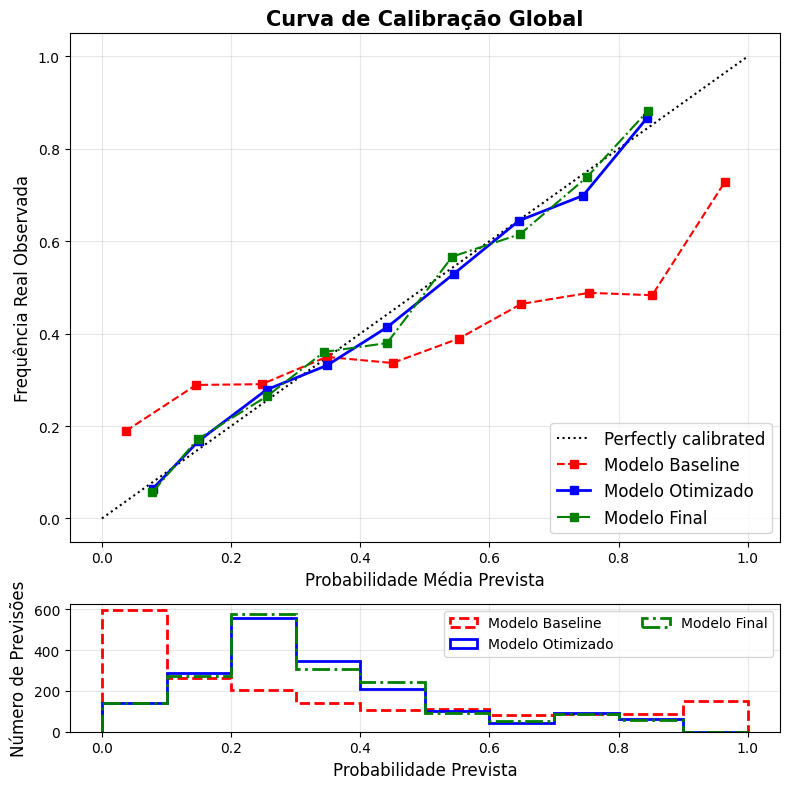

In [30]:
from sklearn.calibration import CalibrationDisplay
from matplotlib.gridspec import GridSpec

y_true_global = Y.ravel()
y_prob_global = y_prob.ravel()
y_prob_final_global = y_prob_final.ravel()
y_prob_final_reduced_global = y_prob_final_reduced.ravel()

fig = plt.figure(figsize=(8,8))
gs = GridSpec(4,1)

ax_calibration = fig.add_subplot(gs[:3, 0])
ax_histogram = fig.add_subplot(gs[3, 0])

# grafico superior curva de calibraçao
disp_base = CalibrationDisplay.from_predictions(y_true_global, y_prob_global, n_bins=10, name="Modelo Baseline", ax=ax_calibration, color='red', linestyle='--')
disp_final = CalibrationDisplay.from_predictions(y_true_global, y_prob_final_global, n_bins=10, name="Modelo Otimizado", ax=ax_calibration, color='blue', linewidth=2)
disp_final_reduced = CalibrationDisplay.from_predictions(y_true_global, y_prob_final_reduced_global, n_bins=10, name="Modelo Final", ax=ax_calibration, color='green', linestyle='-.')

ax_calibration.set_title("Curva de Calibração Global", fontsize=15, fontweight='bold')
ax_calibration.set_xlabel("Probabilidade Média Prevista", fontsize=12)
ax_calibration.set_ylabel("Frequência Real Observada", fontsize=12)
ax_calibration.grid(True, alpha=0.3)
ax_calibration.legend(loc="lower right", fontsize=12)

# grafico inferior histograma de probabilidades
ax_histogram.hist(disp_base.y_prob, range=(0, 1), bins=10, label='Modelo Baseline', histtype="step", lw=2, color='red', linestyle='--')
ax_histogram.hist(disp_final.y_prob, range=(0,1), bins=10, label='Modelo Otimizado', histtype="step", lw=2, color='blue')
ax_histogram.hist(disp_final_reduced.y_prob, range=(0,1), bins=10, label='Modelo Final', histtype="step", lw=2, color='green', linestyle='-.')


ax_histogram.set_xlabel("Probabilidade Prevista", fontsize=12)
ax_histogram.set_ylabel("Número de Previsões", fontsize=12)
ax_histogram.legend(loc="upper right", ncol=2)
ax_histogram.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

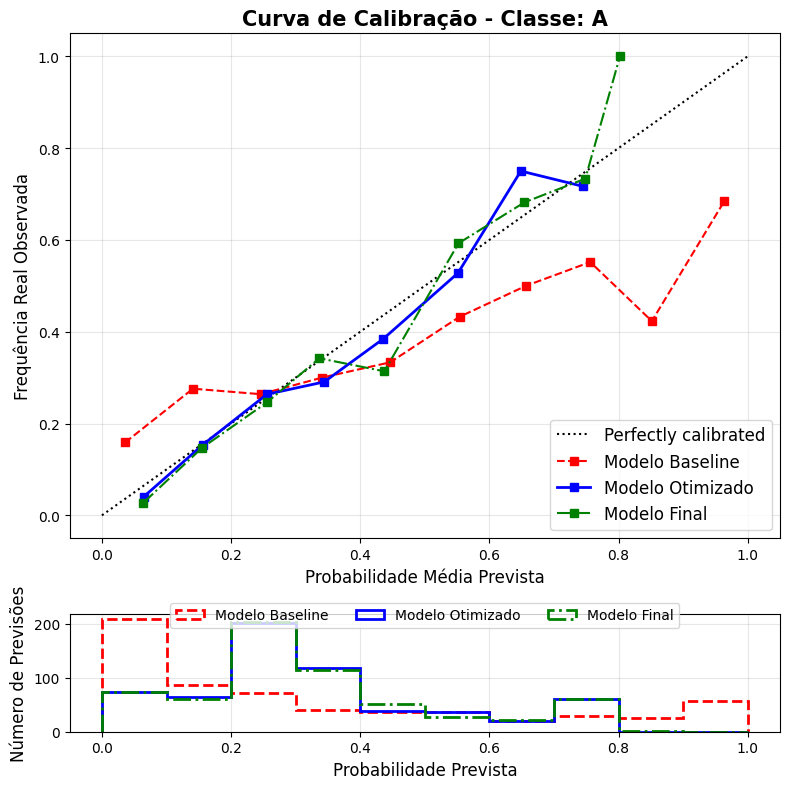

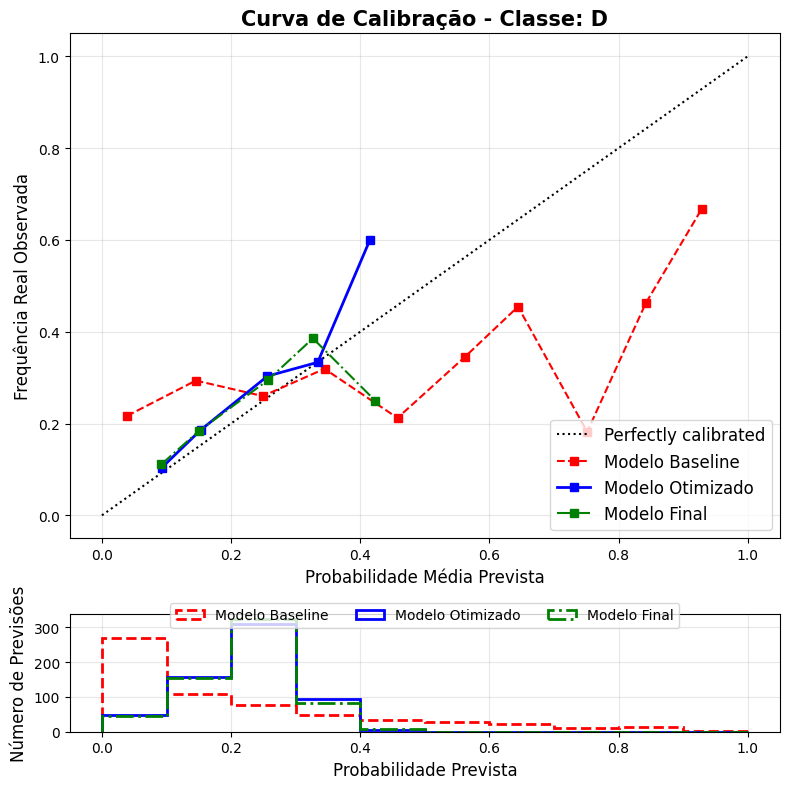

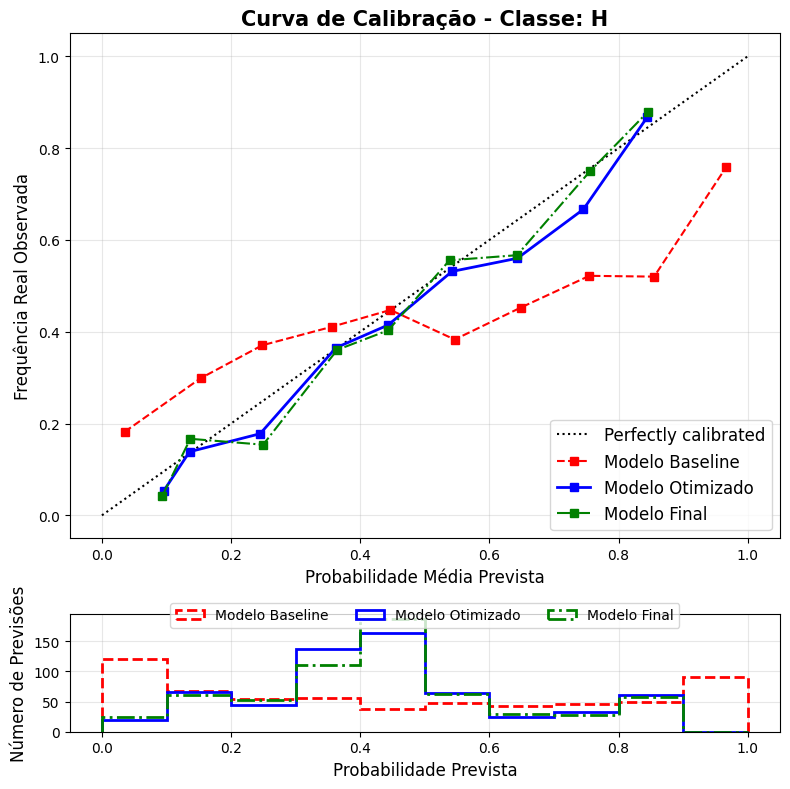

In [31]:
for i, class_label in enumerate(le.classes_):
    
    fig = plt.figure(figsize=(8, 8))
    gs = GridSpec(4, 1)

    ax_calibration = fig.add_subplot(gs[:3, 0])
    ax_histogram = fig.add_subplot(gs[3, 0])

    # extrair apenas as probabilidades e resultados da classe atual
    true_class = Y[:, i]
    prob_base_class = y_prob[:, i]
    prob_opt_class = y_prob_final[:, i]
    prob_red_class = y_prob_final_reduced[:, i]

    # curvas de calibraçao
    disp_base = CalibrationDisplay.from_predictions(
        true_class, prob_base_class, n_bins=10, 
        name="Modelo Baseline", ax=ax_calibration, color='red', linestyle='--'
    )
    disp_final = CalibrationDisplay.from_predictions(
        true_class, prob_opt_class, n_bins=10, 
        name="Modelo Otimizado", ax=ax_calibration, color='blue', linewidth=2
    )
    disp_final_reduced = CalibrationDisplay.from_predictions(
        true_class, prob_red_class, n_bins=10, 
        name="Modelo Final", ax=ax_calibration, color='green', linestyle='-.'
    )

    ax_calibration.set_title(f"Curva de Calibração - Classe: {class_label}", fontsize=15, fontweight='bold')
    ax_calibration.set_xlabel("Probabilidade Média Prevista", fontsize=12)
    ax_calibration.set_ylabel("Frequência Real Observada", fontsize=12)
    ax_calibration.grid(True, alpha=0.3)
    ax_calibration.legend(loc="lower right", fontsize=12)

    # histogramas
    ax_histogram.hist(
        disp_base.y_prob, range=(0, 1), bins=10, 
        label='Modelo Baseline', histtype="step", lw=2, color='red', linestyle='--'
    )
    ax_histogram.hist(
        disp_final.y_prob, range=(0, 1), bins=10, 
        label='Modelo Otimizado', histtype="step", lw=2, color='blue'
    )
    ax_histogram.hist(
        disp_final_reduced.y_prob, range=(0, 1), bins=10, 
        label='Modelo Final', histtype="step", lw=2, color='green', linestyle='-.'
    )

    ax_histogram.set_xlabel("Probabilidade Prevista", fontsize=12)
    ax_histogram.set_ylabel("Número de Previsões", fontsize=12)
    
    ax_histogram.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3, fontsize=10)
    ax_histogram.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Modelo apenas com 2 classes (H e A)

In [32]:
# remover os empates
df_binary = df[df['FTR'] != 'D'].copy()

le_binary = LabelEncoder()
df_binary['FTR_num'] = le_binary.fit_transform(df_binary['FTR'])

mask_train_binary = df_binary['Season'].isin(season_train)
mask_test_binary = df_binary['Season'].isin(season_test)

X_train_binary, X_test_binary = df_binary[features][mask_train_binary], df_binary[features][mask_test_binary]
y_train_binary, y_test_binary = df_binary['FTR_num'][mask_train_binary], df_binary['FTR_num'][mask_test_binary]

model_binary = xgb.XGBClassifier(random_state=42, objective="binary:logistic", eval_metric="logloss")

model_binary.fit(X_train_binary, y_train_binary)
y_pred_proba_binary = model_binary.predict_proba(X_test_binary)
y_pred_binary = model_binary.predict(X_test_binary)

print(f'Accuracy: {accuracy_score(y_test_binary, y_pred_binary):.4f}')
print(f'MCC: {matthews_corrcoef(y_test_binary, y_pred_binary):.4f}')
print(f'F1 Score: {f1_score(y_test_binary, y_pred_binary, average="macro"):.4f}')
print('Classification Report:')
print(classification_report(y_test_binary, y_pred_binary, target_names=le_binary.classes_))
print(f"Log loss: {log_loss(y_test_binary, model_binary.predict_proba(X_test_binary))}")

Accuracy: 0.6800
MCC: 0.3379
F1 Score: 0.6673
Classification Report:
              precision    recall  f1-score   support

           A       0.64      0.57      0.60       192
           H       0.70      0.76      0.73       258

    accuracy                           0.68       450
   macro avg       0.67      0.67      0.67       450
weighted avg       0.68      0.68      0.68       450

Log loss: 0.7795642527892301


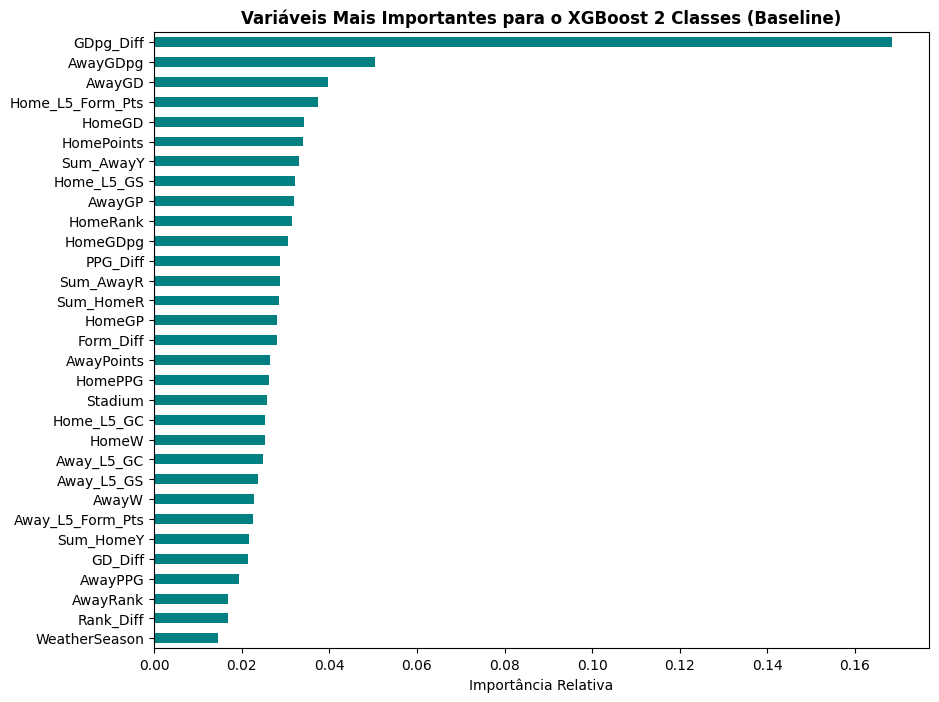

In [33]:
plt.figure(figsize=(10, 8))
final_feat_importances = pd.Series(model_binary.feature_importances_, index=X.columns)
final_feat_importances.nlargest(31).sort_values().plot(kind='barh', color='teal')
plt.title("Variáveis Mais Importantes para o XGBoost 2 Classes (Baseline)", fontweight='bold')
plt.xlabel("Importância Relativa")
plt.show()

Matriz Confusao 2 classes

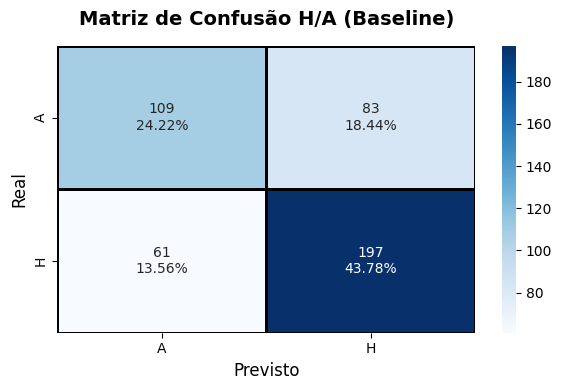

In [34]:
# matriz de confusao
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

# obter contagens e formatar
group_counts = ["{0:0.0f}".format(value) for value in cm_binary.flatten()]

# obter percentagens relativas ao total e formatar
group_percentages = ["{0:.2%}".format(value) for value in cm_binary.flatten()/np.sum(cm_binary)]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts,group_percentages)]

labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(6,4))
sns.heatmap(cm_binary, annot=labels, fmt='', cmap='Blues', xticklabels=le_binary.classes_, yticklabels=le_binary.classes_, linewidths=1, linecolor='black')

plt.title('Matriz de Confusão H/A (Baseline)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Precision Recall Curve 2 classes

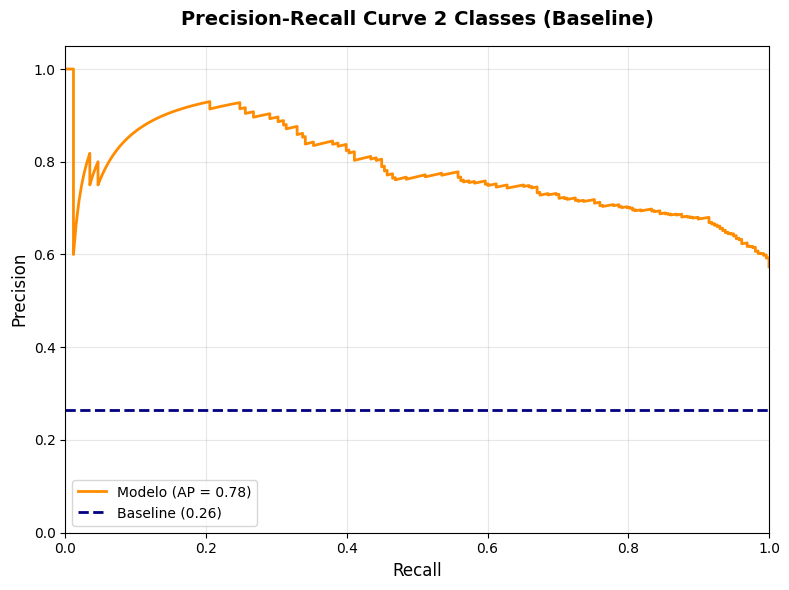

In [35]:
from sklearn.metrics import average_precision_score
y_prob_H = y_pred_proba_binary[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test_binary, y_prob_H)

ap_score = average_precision_score(y_test_binary, y_prob_H)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision, color='darkorange', lw=2, 
         label=f'Modelo (AP = {ap_score:.2f})')

baseline = len(y_test[y_test == 1]) / len(y_test)
plt.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', 
         label=f'Baseline ({baseline:.2f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve 2 Classes (Baseline)', fontsize=14, pad=15, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Optuna 2 Classes

In [36]:
season_train = ['17-18', '18-19', '19-20', '20-21', '21-22']
season_val = ['22-23', '23-24']

mask_train_binary_opt = df_binary['Season'].isin(season_train)
mask_test_binary_opt = df_binary['Season'].isin(season_val)

X_tr_binary, X_val_binary = df_binary[features][mask_train_binary_opt], df_binary[features][mask_test_binary_opt]
y_tr_binary, y_val_binary = df_binary['FTR_num'][mask_train_binary_opt], df_binary['FTR_num'][mask_test_binary_opt]

print(f'Nº jogos de treino (17-18 a 21-22): {len(X_tr_binary)}')
print(f'Nº jogos de teste (22-23 a 23-24): {len(X_val_binary)}')

def objective(trial):
    params ={
        "objective" : "binary:logistic",
        "eval_metric" : "logloss",
        "early_stopping_rounds": 50,
        
        "learning_rate" : trial.suggest_float("learning_rate", 0.005, 0.06, log=True),
        "max_depth" : trial.suggest_int("max_depth", 3, 4),
        "n_estimators" : trial.suggest_int("n_estimators", 400, 1000),
        
        "subsample" : trial.suggest_float("subsample", 0.4, 0.7),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 0.9),
        
        "min_child_weight" : trial.suggest_int("min_child_weight", 6, 10),
        "gamma" : trial.suggest_float("gamma", 2.0, 8.0),
        "reg_lambda" : trial.suggest_float("reg_lambda", 0.05, 2.0, log=True),
        "reg_alpha" : trial.suggest_float("reg_alpha", 0.1, 5.0, log=True)
        }
        
    model_xgb = xgb.XGBClassifier(**params)
    model_xgb.fit(X_tr_binary, y_tr_binary, eval_set=[(X_val_binary, y_val_binary)], verbose=False)
    
    #y_pred_val = model_xgb.predict(X_val_binary)
    y_pred_val_proba = model_xgb.predict_proba(X_val_binary)
    # mcc = matthews_corrcoef(y_val_binary, y_pred_val)
    #f1 = f1_score(y_val_binary, y_pred_val, average="macro")
    loss = log_loss(y_val_binary, y_pred_val_proba)
    
    return loss

Nº jogos de treino (17-18 a 21-22): 1164
Nº jogos de teste (22-23 a 23-24): 482


In [44]:
study_binary = optuna.create_study(direction='minimize')
study_binary.optimize(objective, n_trials=100)
best_params = study_binary.best_params
print(f"Melhores hiperparametros: {best_params}")

best_score = study_binary.best_value
print(f"Melhor Loss: {best_score:.3f}")

[I 2026-05-10 16:53:42,823] A new study created in memory with name: no-name-9de7160c-a7cd-47b0-9b06-4848cc1dc83b
[I 2026-05-10 16:53:43,272] Trial 0 finished with value: 0.5465139858857264 and parameters: {'learning_rate': 0.012137715858341527, 'max_depth': 3, 'n_estimators': 577, 'subsample': 0.5807616138093034, 'colsample_bytree': 0.6076280788022881, 'min_child_weight': 10, 'gamma': 4.354954451160732, 'reg_lambda': 0.1877954671777753, 'reg_alpha': 2.3026647036598176}. Best is trial 0 with value: 0.5465139858857264.
[I 2026-05-10 16:53:44,019] Trial 1 finished with value: 0.5467818763444 and parameters: {'learning_rate': 0.005047863700676821, 'max_depth': 3, 'n_estimators': 806, 'subsample': 0.4626901214535963, 'colsample_bytree': 0.5988791644363178, 'min_child_weight': 9, 'gamma': 7.437462163639837, 'reg_lambda': 0.09226633500463804, 'reg_alpha': 0.9712776162581471}. Best is trial 0 with value: 0.5465139858857264.
[I 2026-05-10 16:53:44,474] Trial 2 finished with value: 0.5484144996

Melhores hiperparametros: {'learning_rate': 0.04635632211048546, 'max_depth': 3, 'n_estimators': 678, 'subsample': 0.4995243416931511, 'colsample_bytree': 0.5426490676090604, 'min_child_weight': 6, 'gamma': 5.2047737369795435, 'reg_lambda': 0.3751488469606916, 'reg_alpha': 0.18389140874211948}
Melhor Loss: 0.540


In [45]:
optuna.visualization.plot_optimization_history(study_binary)

In [46]:
optuna.visualization.plot_slice(study_binary)

In [47]:
optuna.visualization.plot_param_importances(study_binary)

In [37]:
final_binary = xgb.XGBClassifier(random_state=42, objective="binary:logistic",
        learning_rate=0.04635632211048546, max_depth=3, n_estimators=678, subsample=0.4995243416931511, colsample_bytree=0.5426490676090604, min_child_weight=6, gamma=5.2047737369795435, reg_lambda=0.3751488469606916, reg_alpha=0.18389140874211948)

final_binary.fit(X_train_binary, y_train_binary)

y_pred_final_binary = final_binary.predict(X_test_binary)
y_pred_proba_final_binary = final_binary.predict_proba(X_test_binary)

print(f'Accuracy: {accuracy_score(y_test_binary, y_pred_final_binary):.4f}')
print(f'MCC: {matthews_corrcoef(y_test_binary, y_pred_final_binary):.4f}')
print(f1_score(y_test_binary, y_pred_final_binary, average="macro"))
print('Classification Report:')
print(classification_report(y_test_binary, y_pred_final_binary, target_names=le_binary.classes_))
print(f"Log loss: {log_loss(y_test_binary, final_binary.predict_proba(X_test_binary))}")

Accuracy: 0.7133
MCC: 0.4051
0.6961544299689612
Classification Report:
              precision    recall  f1-score   support

           A       0.71      0.56      0.62       192
           H       0.72      0.83      0.77       258

    accuracy                           0.71       450
   macro avg       0.71      0.69      0.70       450
weighted avg       0.71      0.71      0.71       450

Log loss: 0.5437082421364084


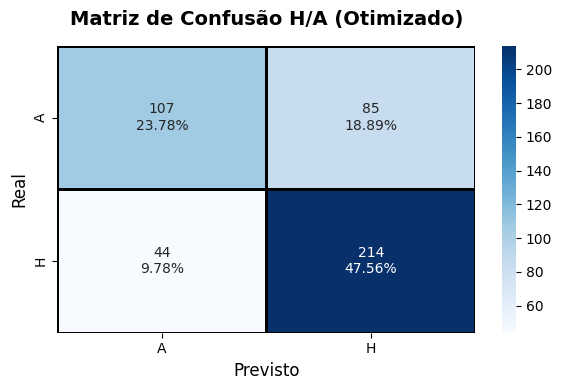

In [38]:
# matriz de confusao
cm_binary_final = confusion_matrix(y_test_binary, y_pred_final_binary)

# obter contagens e formatar
group_counts = ["{0:0.0f}".format(value) for value in cm_binary_final.flatten()]

# obter percentagens relativas ao total e formatar
group_percentages = ["{0:.2%}".format(value) for value in cm_binary_final.flatten()/np.sum(cm_binary_final)]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts,group_percentages)]

labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(6,4))
sns.heatmap(cm_binary_final, annot=labels, fmt='', cmap='Blues', xticklabels=le_binary.classes_, yticklabels=le_binary.classes_, linewidths=1, linecolor='black')

plt.title('Matriz de Confusão H/A (Otimizado)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

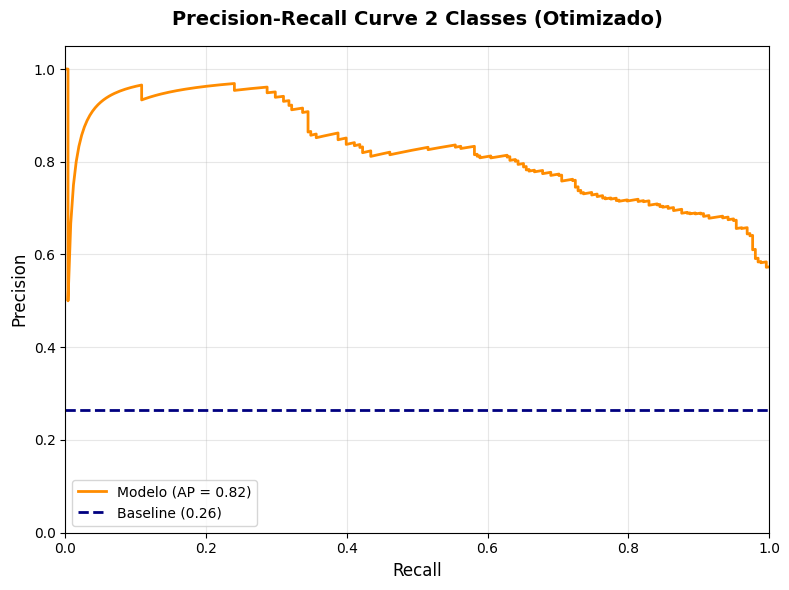

In [39]:
y_prob_H_final = y_pred_proba_final_binary[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test_binary, y_prob_H_final)

ap_score = average_precision_score(y_test_binary, y_prob_H_final)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision, color='darkorange', lw=2, 
         label=f'Modelo (AP = {ap_score:.2f})')

baseline = len(y_test[y_test == 1]) / len(y_test)
plt.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', 
         label=f'Baseline ({baseline:.2f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve 2 Classes (Otimizado)', fontsize=14, pad=15, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

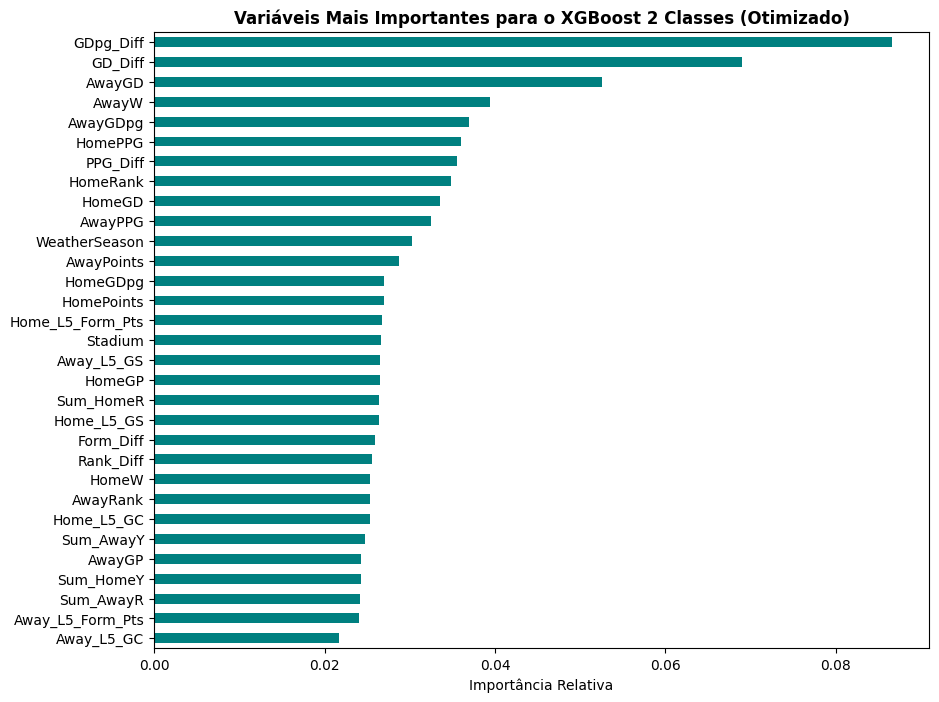

In [45]:
plt.figure(figsize=(10, 8))
final_feat_importances = pd.Series(final_binary.feature_importances_, index=X.columns)
final_feat_importances.nlargest(31).sort_values().plot(kind='barh', color='teal')
plt.title("Variáveis Mais Importantes para o XGBoost 2 Classes (Otimizado)", fontweight='bold')
plt.xlabel("Importância Relativa")
plt.show()

In [42]:
brier_base_binary = brier_score_loss(y_test_binary, y_prob_H)
brier_final_binary = brier_score_loss(y_test_binary, y_prob_H_final)

print(f"Brier Score (Baseline):  {brier_base_binary:.4f}")
print(f"Brier Score (Otimizado): {brier_final_binary:.4f}")

Brier Score (Baseline):  0.2324
Brier Score (Otimizado): 0.1840


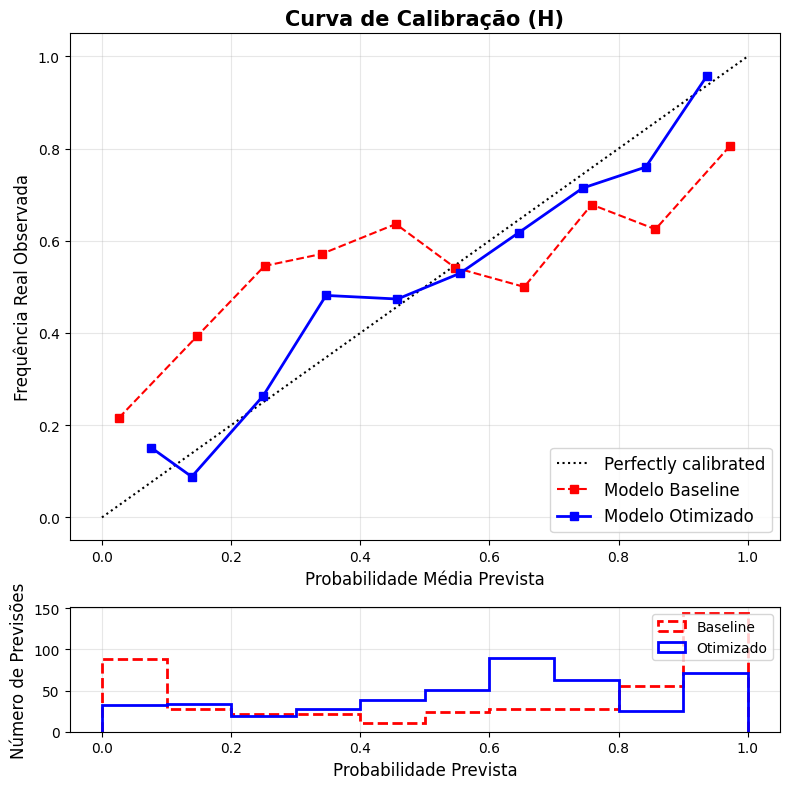

In [43]:
prob_H_base = model_binary.predict_proba(X_test_binary)[:, 1]
prob_H_final = final_binary.predict_proba(X_test_binary)[:, 1]

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(4, 1)
ax_calibration = fig.add_subplot(gs[:3, 0])
ax_histogram = fig.add_subplot(gs[3, 0])

disp_base = CalibrationDisplay.from_predictions(
    y_test_binary, prob_H_base, n_bins=10, 
    name="Modelo Baseline", ax=ax_calibration, color='red', linestyle='--'
)
disp_final = CalibrationDisplay.from_predictions(
    y_test_binary, prob_H_final, n_bins=10, 
    name="Modelo Otimizado", ax=ax_calibration, color='blue', linewidth=2
)

ax_calibration.set_title("Curva de Calibração (H)", fontsize=15, fontweight='bold')
ax_calibration.set_xlabel("Probabilidade Média Prevista", fontsize=12)
ax_calibration.set_ylabel("Frequência Real Observada", fontsize=12)
ax_calibration.grid(True, alpha=0.3)
ax_calibration.legend(loc="lower right", fontsize=12)

ax_histogram.hist(
    disp_base.y_prob, range=(0, 1), bins=10, 
    label='Baseline', histtype="step", lw=2, color='red', linestyle='--'
)
ax_histogram.hist(
    disp_final.y_prob, range=(0, 1), bins=10, 
    label='Otimizado', histtype="step", lw=2, color='blue'
)

ax_histogram.set_xlabel("Probabilidade Prevista", fontsize=12)
ax_histogram.set_ylabel("Número de Previsões", fontsize=12)
ax_histogram.legend(loc="upper right")
ax_histogram.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

# carregar dados
df = pd.read_csv("../data/processed/LigaPortugal17-26.csv")

# ordenar por data, mais antigo primeiro
df = df.sort_values(by=['Date', 'Time', 'HomeTeam'], ascending=[True, True, True]).reset_index(drop=True)
#df = df.iloc[::-1].reset_index(drop=True)

future_games = df[df['FTR'].isna()].copy()

probs = final_model.predict_proba(future_games[features])
probs1 = model_xgb.predict_proba(future_games[features])
probs2 = modelo_reduced.predict_proba(future_games[features_reduced])

for i in range(len(future_games)):
    equipa_casa = future_games.iloc[i]['HomeTeam']
    equipa_fora = future_games.iloc[i]['AwayTeam']
    print("Otimizado")
    print(f"{equipa_casa}: {probs[i][2] * 100:.1f}% - Empate: {probs[i][1] * 100:.1f}% - {equipa_fora}: {probs[i][0] * 100:.1f}%")
    print("Baseline")
    print(f"{equipa_casa}: {probs1[i][2] * 100:.1f}% - Empate: {probs1[i][1] * 100:.1f}% - {equipa_fora}: {probs1[i][0] * 100:.1f}%")
    print("Otimizado Reduzido")
    print(f"{equipa_casa}: {probs2[i][2] * 100:.1f}% - Empate: {probs2[i][1] * 100:.1f}% - {equipa_fora}: {probs2[i][0] * 100:.1f}%")
    print("-" * 50)

Otimizado
AVS: 11.2% - Empate: 14.9% - Porto: 73.9%
Baseline
AVS: 2.3% - Empate: 0.9% - Porto: 96.9%
Otimizado Reduzido
AVS: 12.6% - Empate: 14.1% - Porto: 73.3%
--------------------------------------------------
Otimizado
Alverca: 48.3% - Empate: 22.2% - Estoril: 29.5%
Baseline
Alverca: 46.5% - Empate: 9.4% - Estoril: 44.1%
Otimizado Reduzido
Alverca: 38.7% - Empate: 29.1% - Estoril: 32.2%
--------------------------------------------------
Otimizado
Benfica: 63.0% - Empate: 18.1% - Sp Braga: 18.9%
Baseline
Benfica: 69.1% - Empate: 5.4% - Sp Braga: 25.5%
Otimizado Reduzido
Benfica: 62.8% - Empate: 20.8% - Sp Braga: 16.4%
--------------------------------------------------
Otimizado
Estrela: 21.6% - Empate: 28.8% - Famalicao: 49.6%
Baseline
Estrela: 24.6% - Empate: 13.6% - Famalicao: 61.8%
Otimizado Reduzido
Estrela: 23.2% - Empate: 30.2% - Famalicao: 46.6%
--------------------------------------------------
Otimizado
Gil Vicente: 42.5% - Empate: 34.1% - Arouca: 23.4%
Baseline
Gil Vicente